In [438]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from scipy import stats
from scipy.special import erfcinv
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initialization

In [439]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [440]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[:30]
depth = depth - np.nanmin(depth)
conc = conc[:, :30]

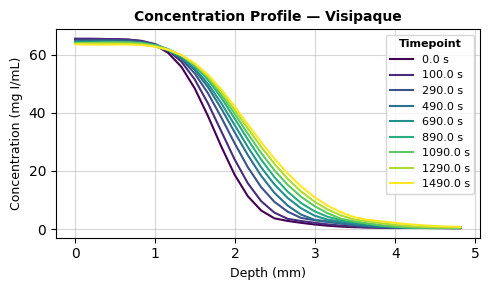

In [441]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/vis_prof_1d.png", dpi = 400, transparent = True)
plt.show()

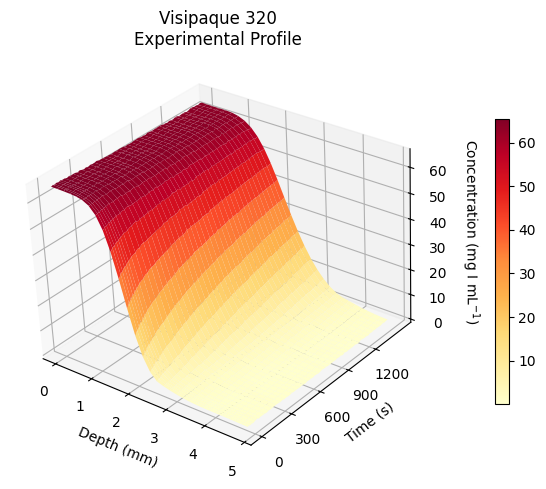

In [442]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/vis_prof_2d.png", dpi = 400, transparent = True)
plt.show()

# ICD Method

In [443]:
def icd_method(c_null, conc, time, depth, shift = True):
    try:
        ### Determine concentration-front position at each time
        t_front = np.sqrt(time)
        x_front = []
        cs_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        x_front = np.array(x_front)

        valid_front = np.isfinite(x_front) & np.isfinite(t_front)

        t_front_valid = t_front[valid_front]
        x_front_valid = x_front[valid_front]

        # Fit x_front vs sqrt(time)
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            t_front_valid, x_front_valid)

        # Calculate D from slope
        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        # Confidence intervals
        n = len(x_front_valid)
        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - marg_of_err
        slope_upper = slope + marg_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # Restrict profile comparison to x > x0 if requested
        start_idx = np.searchsorted(depth, intercept, side = "right") if shift else 0

        cs_idx = np.searchsorted(depth, intercept)
        cs_start = np.nanmean(conc[:, cs_idx])

        depth_fit = depth[start_idx:]
        conc_fit = conc[:, start_idx:]

        # Geerate model concentration profiles
        sim_conc = np.zeros_like(conc_fit)

        for i, ti in enumerate(time):
            if ti == 0:
                sim_conc[i, :] = models.semi_infinite(
                    depth_fit,
                    intercept,
                    d_front,
                    cs_start,
                    0.001
                )
            else:
                sim_conc[i, :] = models.semi_infinite(
                    depth_fit,
                    intercept,
                    d_front,
                    cs_start,
                    ti
                )

        # Calculate residuals and r2
        mask = np.isfinite(conc_fit) & np.isfinite(sim_conc)
        
        residuals = conc_fit[mask] - sim_conc[mask]

        n_profile = residuals.size
        p = 2 # D and x0 fitted

        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((conc_fit[mask] - np.nanmean(conc_fit[mask]))**2)

        rse = np.sqrt(ss_res / (n_profile - p))

        r2_profile = 1 - ss_res / ss_tot

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2_front"      : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept,
            "rse"           : rse,
            "r2_profile"    : r2_profile,
            "start_idx"     : start_idx
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [444]:
c_null_list = [5, 10, 20, 30, 40]
icd_results = [icd_method(c_null, conc, time, depth) for c_null in c_null_list]

In [445]:
rows = []
for r in icd_results:
    row = {
        "c_null": r["c_null"],
        "d": r["d"],
        "d_ci": r["ci_d"],
        "x_0": r["intercept"],
        "pc_dec": (2.13e-4 - r["d"]) / 2.13e-4 * 100,
        "r2_front": r["r2_front"],
        "r2_profile": r["r2_profile"],
        "rse": r["rse"]
    }
    rows.append(row)

icd_df = pd.DataFrame(rows)
icd_df

,c_null,d,d_ci,x_0,pc_dec,r2_front,r2_profile,rse
0,5,0.000129,"(0.00012245354762011225, 0.00013560198059157629)",2.253692,39.462926,0.987207,0.767805,3.100528
1,10,0.000141,"(0.00013424097749045253, 0.00014720996166402798)",2.082389,33.966793,0.989515,0.785701,3.846771
2,20,0.000163,"(0.00015706839252490893, 0.0001689350708089908)",1.890645,23.498723,0.993434,0.760640,5.122626
3,30,0.000199,"(0.00019329940409918092, 0.00020428358211477788)",1.745539,6.688473,0.996208,0.797479,5.772004
4,40,0.000269,"(0.0002630062546026847, 0.00027463022361557115)",1.604316,-26.190996,0.997675,0.838814,6.115417


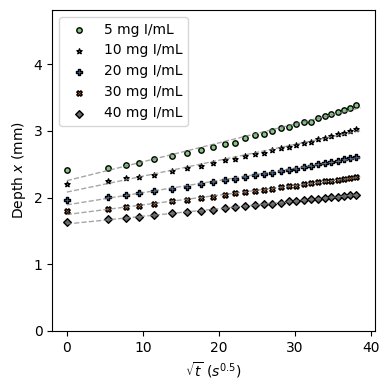

In [446]:
fig, ax = plt.subplots(figsize = (4, 4))
cats = [str(c) + " mg I /mL" for c in c_null_list]
markers = ["o", "*", "P", "X", "D"]
colors = plt.cm.Accent(np.linspace(0, 1, len(cats)))

for i, r in enumerate(icd_results):
        t_front = r["t_0.5"]
        x_front = r["iso_front"]
        c_null = r["c_null"]
        intercept = r["intercept"]
        slope = r["slope"]

        ax.scatter(t_front[::3], x_front[::3], 
                marker = markers[i], 
                edgecolors = "black", 
                facecolors = colors[i], 
                s  = 15,
                label = f"{c_null} mg I/mL")
        ax.set_xlabel(f"$\\sqrt{{t}}$ ($s^{{0.5}}$)")
        ax.set_ylabel(f"Depth $x$ (mm)")

        # plot regression line
        x_reg = np.linspace(0, np.nanmax(t_front), len(t_front))
        y_reg = slope * x_reg + intercept
        ax.plot(x_reg, y_reg, 
                linestyle = "--",
                c = "grey",
                alpha = 0.7,
                linewidth = 1)
ax.set_ylim(0, np.nanmax(depth))
plt.legend()  
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/vis_icd.png", dpi = 400, transparent = True)
plt.show()

In [447]:
def conc_sim(result, depth, time, cs_exp):
    out = np.zeros((len(time), len(depth)))
    for i, ti in enumerate(time):
        if ti == 0:
            ti = 0.001
        out[i, :] = models.semi_infinite(depth, 
                                        result["intercept"], 
                                        result["d"],
                                        cs_exp,
                                        ti)

    return out

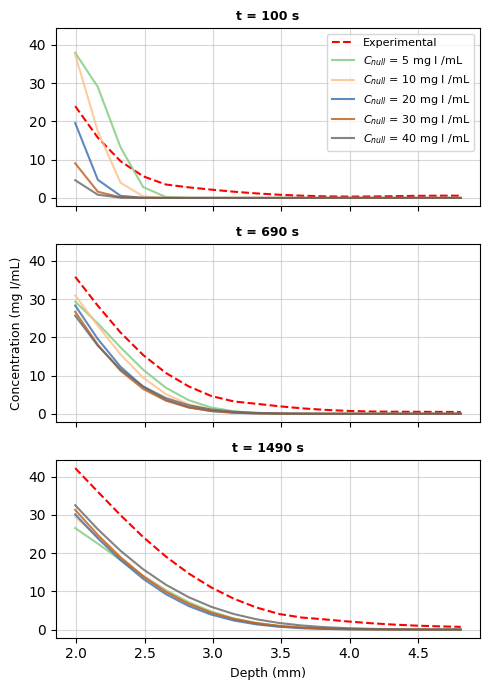

In [448]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
idx_cs = [np.searchsorted(depth, r["intercept"]) for r in icd_results]
cs_exp = [np.nanmean(conc[:, i]) for i in idx_cs]

from matplotlib.lines import Line2D

profs = [10, len(time)//2, len(time)-1]
c_null_list = c_null_list

conc_sims = [conc_sim(r, depth, time, cs) for r, cs in zip(icd_results, cs_exp)]

colors = plt.cm.Accent(np.linspace(0, 1, len(c_null_list)))

linestyles = ["-", "--", ":"]

fig, ax = plt.subplots(3, 1, figsize=(5, 7), sharex=True, sharey=True)

for j, i in enumerate(profs):

    # Experimental profile
    ax[j].plot(
        depth[12:],
        conc[i, 12:],
        color="r",
        label="Experimental",
        linestyle = "--"
    )

    # Fitted profiles for each c_null
    for k, c_null in enumerate(c_null_list):
        ax[j].plot(
            depth[12:],
            conc_sims[k][i, 12:],
            color=colors[k],
            label=f"$C_{{null}}$ = {c_null} mg I /mL",
            linestyle = "-",
            alpha = 0.8
        )

    ax[j].grid(alpha=0.5)

    ax[j].set_title(
        f"t = {time[i]:.0f} s",
        loc="center",
        fontdict={"weight": "bold", "size": 9}
    )

ax[-1].set_xlabel("Depth (mm)", size=9)
ax[1].set_ylabel("Concentration (mg I/mL)", size=9)
# Only show one legend to avoid repetition
ax[0].legend(
    fontsize=8,
    title_fontproperties={"weight": "bold", "size": 8}
)

plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/icd_sim.png", dpi = 400, transparent = True)
plt.show()

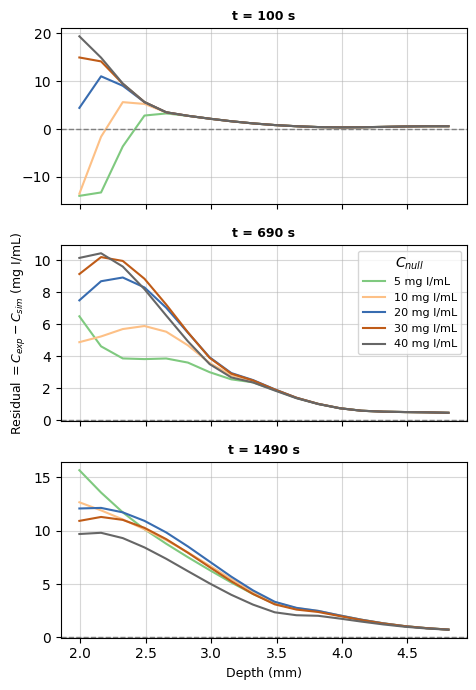

In [449]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
idx_cs = [np.searchsorted(depth, r["intercept"]) for r in icd_results]
cs_exp = [np.nanmean(conc[:, i]) for i in idx_cs]

from matplotlib.lines import Line2D

profs = [10, len(time)//2, len(time)-1]
c_null_list = c_null_list

conc_sims = [conc_sim(r, depth, time, cs) for r, cs in zip(icd_results, cs_exp)]

colors = plt.cm.Accent(np.linspace(0, 1, len(c_null_list)))

linestyles = ["-", "--", ":"]

fig, ax = plt.subplots(3, 1, figsize=(5, 7), sharex=True)

for j, i in enumerate(profs):
    # relative residuals for each c_null
    for k, c_null in enumerate(c_null_list):
        residual =  conc[i, 12:] - conc_sims[k][i, 12:]

        ax[j].plot(
            depth[12:],
            residual,
            color = colors[k],
            label = f"{c_null_list[k]} mg I/mL"
        )
    # zero reference line
    ax[j].axhline(
        0,
        color = "grey",
        linestyle = "--",
        linewidth = 1
    )

    ax[j].set_title(
        f"t = {time[i]:.0f} s",
        loc = "center",
        fontdict = {"weight": "bold", "size": 9}
    )

    ax[j].grid(alpha = 0.5)

ax[1].set_ylabel(f"Residual $= C_{{exp}} - C_{{sim}}$ (mg I/mL)", size = 9)
ax[-1].set_xlabel("Depth (mm)", size = 9)

# c_null legend
ax[1].legend(title = f"$C_{{null}}$", fontsize = 8, loc = "upper right")
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/icd_sim_residuals.png", dpi = 400, transparent = True)
plt.show()

# No Manual Boundary

In [450]:
# No boundary, so fitting with x0
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs.append(cfg)

In [451]:
results_x0 = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results_x0.append(result)
        bar()

Fitting configs |                                        | ▁▃▅ 0/2 [0%] in 0s (~

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


# With Manual Boundary

In [452]:
dat = import_dat(boundary = True)

conc_b, depth_b, time_b = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth_b = depth_b.flatten()
time_b = time_b.flatten()

depth_b = depth_b[:30]
conc_b = conc_b[:, :30]
time_b = time_b

In [453]:
# No boundary, so fitting with x0
configs_b = []
cs_exp = np.nanmean(conc_b[:, 0])
d_mode = "global"

for fit_x0 in [False]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs_b.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs_b.append(cfg)

In [454]:
results_semi = []
with alive_bar(len(configs_b), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_b:
        result = fitting.fit_diffusion(conc_b, depth_b, time_b, cfg)
        results_semi.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


## Plotting results for results_x0[0] (global Cs, global x0)

In [455]:
semi_inf = models.semi_infinite
conc_sim = np.empty_like(conc)
mod = results_x0[0]

for i, ti in enumerate(time):
    if ti == 0:
        conc_sim[i, :] = semi_inf(depth, mod.x0_global, mod.d_global, mod.cs_global, 0.001)
    else:
        conc_sim[i, :] = semi_inf(depth, mod.x0_global, mod.d_global, mod.cs_global, ti)

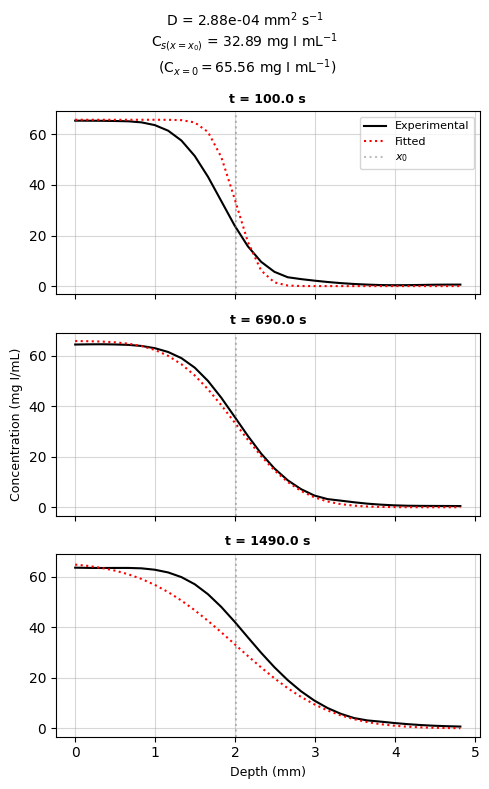

In [456]:
from matplotlib.lines import Line2D

profs = [10, len(time)//2, len(time)-1]

fig, ax = plt.subplots(3, 1, figsize=(5, 8), sharex=True, sharey=True)

for j, i in enumerate(profs):

    # Experimental profile
    ax[j].plot(
        depth,
        conc[i, :],
        color="k",
        label="Experimental",
        linestyle = "-"
    )

    ax[j].plot(
        depth,
        conc_sim[i, :],
        color = "r",
        label = "Fitted",
        linestyle = ":"
    )

    ax[j].set_title(f"t = {time[i]} s",
                    fontdict = {"weight": "bold",
                                "size": 9})

    ax[j].axvline(x = mod.x0_global, 
                  linestyle = ":", 
                  alpha = 0.5, 
                  color = "grey",
                  lw = 1.5,
                  label = f"$x_0$")
    ax[j].grid(alpha = 0.5)

ax[-1].set_xlabel("Depth (mm)", size=9)
ax[1].set_ylabel("Concentration (mg I/mL)", size=9)
# Only show one legend to avoid repetition
ax[0].legend(
    fontsize=8,
    title_fontproperties={"weight": "bold", "size": 8}
)
fig.suptitle(f"D = {mod.d_global:.2e} mm$^2$ s$^{{-1}}$\n"
             f"C$_{{s (x=x_0)}}$ = {mod.cs_global:.2f} mg I mL$^{{-1}}$ \n (C$_{{x=0}} = ${np.nanmean(conc_sim[:, 0]):.2f} mg I mL$^{{-1}}$)",
             size = 10)

plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/dg_x0g_sim.png", dpi = 400, transparent = True)
plt.show()


Earlier timepoints - underestimated, later timepoint - overestimated
- Shallower depths/earlier timepoints --> transient non-Fickian processes driving diffusion
- At later timepoints, diffusion becomes a more dominant

In [457]:
def sim_residual(d, cs, conc, time, depth, x0 = 0):
    semi_inf = models.semi_infinite
    conc_sim = np.empty_like(conc)

    for i, ti in enumerate(time):
        if ti == 0:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, 0.001)
        else:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, ti)

    n = conc.size
    p = 1

    residuals = (conc - conc_sim) / conc * 100
    return residuals

In [458]:
results_combined = results_x0 + results_semi
depth_combined = [depth] + [depth] + [depth_b] + [depth_b]
time_combined = [time] + [time] + [time_b] + [time_b]
conc_combined = [conc] + [conc] + [conc_b] + [conc_b]
titles_combined = [f"Semi-infinite with $x_0$", 
                   f"Semi-infinite with $x_0$ (Fixed C$_s$)",
                   f"Manually Selected Boundary",
                   f"Manually Selected Boundary (Fixed C$_s$)"
                   ]
residuals = []

for r, conc, depth, time in zip(results_combined, conc_combined, depth_combined, time_combined):
    d = r.d_global
    cs = cs_exp
    x0 = 0 if r.x0_global is None else r.x0_global

    res = sim_residual(d, cs, conc, time, depth, x0)
    residuals.append(res)


In [459]:
# Exporting data to dfs
rows = []
for r in results_combined:
    cfg = r.config

    d_summary = r.d_global
    cs_summary = r.cs_global
    x0_summary = r.x0_global if cfg.fit_x0 else np.nan

    if cfg.fit_x0:
        d_ci = (r.lb_all[1], r.ub_all[1])
        x0_ci = (r.lb_all[0], r.ub_all[0])
        cs_ci = (r.lb_all[2], r.ub_all[2]) if cfg.cs_mode == "global" else (np.nan, np.nan)
    else:
        d_ci = (r.lb_all[0], r.ub_all[0])
        cs_ci = (r.lb_all[1], r.ub_all[1]) if cfg.cs_mode == "global" else (np.nan, np.nan)
        x0_ci = (np.nan, np.nan)

    rows.append({
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "fit_x0": cfg.fit_x0,
        "d": d_summary,
        "cs": cs_summary,
        "x0": x0_summary,
        "r2": r.r2_global,
        "rse": r.rse_global,
        "d_ci": d_ci,
        "cs_ci": cs_ci,
        "x0_ci": x0_ci,
        "aic": r.aic
    })

In [460]:
summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["aic"] - summary_df["aic"].min()
summary_df

,d_mode,cs_mode,fit_x0,d,cs,x0,r2,rse,d_ci,cs_ci,x0_ci,aic,delta_aic
0,global,global,True,0.000288,32.888158,2.008024,0.977760,4.054208,"(0.0002751996234937035, 0.00030011744459948643)","(32.713660838468904, 33.06265480705594)","(2.0002066159654466, 2.015842299319378)",6721.823877,0.000000
1,global,fixed,True,0.002982,64.449782,0.628168,0.797592,12.228271,"(0.002827607870709701, 0.0031361316495561544)","(nan, nan)","(0.6053201872878188, 0.651015954881449)",12020.001692,5298.177815
2,global,global,False,0.001021,66.776276,NaN,0.923139,5.480010,"(0.0009883859655825124, 0.0010545481006320402)","(65.99904725902084, 67.55350377453593)","(nan, nan)",8167.312510,1445.488634
3,global,fixed,False,0.001159,61.624955,NaN,0.917527,5.675357,"(0.001126007523214817, 0.0011918995284615403)","(nan, nan)","(nan, nan)",8334.440108,1612.616232


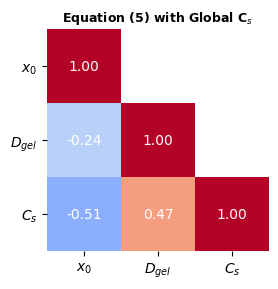

In [461]:
corr_list = [results_combined[0].corr, results_combined[2].corr]
masks = [np.triu(np.ones_like(corr, dtype = bool), k = 1) for corr in corr_list]
corr_list_m = [np.ma.masked_where(mask, corr) for mask, corr in zip(masks, corr_list)]

labels = [f"$x_0$", f"$D_{{gel}}$", f"$C_s$"]

fig, ax = plt.subplots(figsize = (3, 3))
corr = corr_list_m[0]
ax.imshow(corr,
          vmin = -1,
          vmax = 1,
          cmap = "coolwarm")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        if i >= j:
            ax.text(
                j, i,
                f"{corr[i, j]:.2f}",
                ha = "center",
                va = "center",
                color = "w"
            )

ax.set_title(f"Equation (5) with Global C$_s$", fontdict = {"weight": "bold",
                                                            "size": 9})

for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/corr_matrix_5.png", dpi = 400, transparent = True)
plt.show()

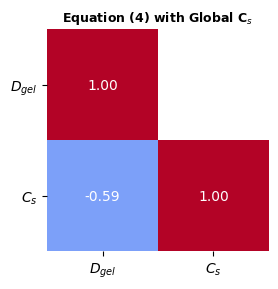

In [462]:
corr_list = [results_combined[0].corr, results_combined[2].corr]
masks = [np.triu(np.ones_like(corr, dtype = bool), k = 1) for corr in corr_list]
corr_list_m = [np.ma.masked_where(mask, corr) for mask, corr in zip(masks, corr_list)]

labels = [f"$D_{{gel}}$", f"$C_s$"]

fig, ax = plt.subplots(figsize = (3, 3))
corr = corr_list_m[1]
ax.imshow(corr,
          vmin = -1,
          vmax = 1,
          cmap = "coolwarm")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        if i >= j:
            ax.text(
                j, i,
                f"{corr[i, j]:.2f}",
                ha = "center",
                va = "center",
                color = "w"
            )

ax.set_title(f"Equation (4) with Global C$_s$", fontdict = {"weight": "bold",
                                                            "size": 9})

for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.savefig("/Volumes/Coolens_Research/Isaac/Experiments/pcl2201_paper/figures/corr_matrix_5.png", dpi = 400)
plt.show()

# Shifting timepoints

In [463]:
valid_indices = [np.arange(len(time))[i:] for i in range(0, len(time) - 10, 5)]

In [464]:
# No boundary, so fitting with x0
configs_shift = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True, False]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        for idx in valid_indices:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (-np.inf, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp,
                    fit_indices = idx
                )
                configs_shift.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (-np.inf, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    fit_indices = idx
                )
                configs_shift.append(cfg)

In [465]:
results_shift = {}
with alive_bar(len(configs_shift), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_shift:
        if cfg.fit_x0:
            result = fitting.fit_diffusion(conc, depth, time, cfg)
        else:
            result = fitting.fit_diffusion(conc_b, depth_b, time_b, cfg)
        cs_mode = cfg.cs_mode
        x0_mode = "autox0" if cfg.fit_x0 else "manualx0"
        key = cs_mode + "_" + x0_mode

        if key not in results_shift.keys():
            results_shift[key] = []

        results_shift[key].append(result)
        
        bar()

Fitting configs |████████████████████████████████████████| 60/60 [100%] in 0.6s 


In [466]:
for key in results_shift.keys():
    print("----------")
    print(f"{key}")
    print("----------")
    for r in results_shift[key]:
            print(f"Starting at {r.valid_times[0]} s: D = {r.d_global:.2e} mm2/s, Cs = {r.cs_global:.2f} (r2 = {r.r2_global:.3f})")

----------
global_autox0
----------
Starting at 10.0 s: D = 4.77e-04 mm2/s, Cs = 37.99 (r2 = 0.962)
Starting at 50.0 s: D = 5.41e-04 mm2/s, Cs = 41.25 (r2 = 0.972)
Starting at 100.0 s: D = 5.43e-04 mm2/s, Cs = 43.23 (r2 = 0.981)
Starting at 190.0 s: D = 4.89e-04 mm2/s, Cs = 42.62 (r2 = 0.987)
Starting at 290.0 s: D = 4.10e-04 mm2/s, Cs = 40.23 (r2 = 0.990)
Starting at 390.0 s: D = 3.48e-04 mm2/s, Cs = 38.22 (r2 = 0.992)
Starting at 490.0 s: D = 3.10e-04 mm2/s, Cs = 37.05 (r2 = 0.994)
Starting at 590.0 s: D = 2.85e-04 mm2/s, Cs = 36.33 (r2 = 0.995)
Starting at 690.0 s: D = 2.67e-04 mm2/s, Cs = 35.87 (r2 = 0.996)
Starting at 790.0 s: D = 2.54e-04 mm2/s, Cs = 35.55 (r2 = 0.997)
Starting at 890.0 s: D = 2.44e-04 mm2/s, Cs = 35.32 (r2 = 0.997)
Starting at 990.0 s: D = 2.37e-04 mm2/s, Cs = 35.19 (r2 = 0.998)
Starting at 1090.0 s: D = 2.31e-04 mm2/s, Cs = 35.07 (r2 = 0.998)
Starting at 1190.0 s: D = 2.27e-04 mm2/s, Cs = 35.08 (r2 = 0.998)
Starting at 1290.0 s: D = 2.24e-04 mm2/s, Cs = 35.09 (

In [467]:
depth

array([0.   , 0.166, 0.332, 0.498, 0.664, 0.83 , 0.996, 1.162, 1.328,
       1.494, 1.66 , 1.826, 1.992, 2.158, 2.324, 2.49 , 2.656, 2.822,
       2.988, 3.154, 3.32 , 3.486, 3.652, 3.818, 3.984, 4.15 , 4.316,
       4.482, 4.648, 4.814])

In [468]:
import copy
import numpy as np

def fit_diffusion_profile_likelihood(c_xt, x, t, config: fitting.FitConfig, n_grid_steps: int = 50) -> fitting.FitResults:
    """
    Executes a Profile-Likelihood Coordinate Descent optimization by isolating x0 on a grid
    and optimizing Cs and D globally at each coordinate step.
    """
    # 1. Fallback to normal fit if user doesn't want to fit x0 or bounds aren't set
    if not config.fit_x0:
        return fitting.fit_diffusion(c_xt, x, t, config)
    
    # 2. Establish your deterministic grid search boundaries for x0
    # Uses the bounds defined in your post_init
    x0_min, x0_max = config.x0_bounds
    x0_grid = np.linspace(x0_min, x0_max, n_grid_steps)
    
    best_rss = np.inf
    best_results = None
    best_x0_val = None
    
    # We will temporarily modify the configuration for the internal runs
    # We duplicate the config to prevent changing the user's original settings
    grid_config = copy.deepcopy(config)
    
    # IMPORTANT TRICK: Turn off fit_x0 internally because we are manually stepping through it.
    # We inject the fixed x0 candidate into our math landscape.
    grid_config.fit_x0 = False 
    
    # 3. Coordinate Descent Loop: Step across the x0 axis
    for x0_candidate in x0_grid:
        
        # Monkey-patch the model wrapper or adjust your model_fn to respect a fixed x0.
        # Since your MODEL_REGISTRY expects model_fn(x, x0, d, cs, t), we intercept it
        # by temporarily replacing the registered function with a partial function tracking our candidate.
        original_model_fn = fitting.MODEL_REGISTRY[config.model]
        fitting.MODEL_REGISTRY[config.model] = lambda _x, _x0, _d, _cs, _t: original_model_fn(_x, x0_candidate, _d, _cs, _t)
        
        try:
            # Execute your robust global/per-timepoint fit for Cs and D
            current_results = fitting.fit_diffusion(c_xt, x, t, grid_config)
            
            # Skip if the NLS optimizer failed to converge at this coordinate step
            if current_results.pcov is None:
                fitting.MODEL_REGISTRY[config.model] = original_model_fn  # Reset registry before jumping
                continue
                
            # 4. Calculate Residual Sum of Squares (RSS) to track the likelihood profile
            # We reconstruct your concatenated vectors to evaluate global performance
            model_fn = original_model_fn
            x_segments, c_segments, valid_times, _ = fitting._collect_segments(
                c_xt, x, t, config.fit_indices, config.min_points
            )
            
            rss = 0.0
            for seg_idx, (x_seg, c_seg, t_seg) in enumerate(zip(x_segments, c_segments, valid_times)):
                # Fetch parameters extracted by your _unpack_results mapping
                d_val = current_results.d_global if grid_config.d_mode == "global" else current_results.d_per_t[seg_idx]
                cs_val = current_results.cs_global if grid_config.cs_mode == "global" else current_results.cs_per_t[seg_idx]
                
                # Compare against the true analytical function
                pred_c = model_fn(x_seg, x0_candidate, d_val, cs_val, t_seg)
                rss += np.sum((c_seg - pred_c) ** 2)
            
            # 5. Identify if this x0 coordinate yields a superior global fit
            if rss < best_rss:
                best_rss = rss
                best_results = current_results
                best_x0_val = x0_candidate
                
        except Exception as e:
            print(f"Grid step x0={x0_candidate:.4f} failed: {e}")
        finally:
            # ALWAYS restore your global model registry back to its un-patched state
            fitting.MODEL_REGISTRY[config.model] = original_model_fn

    # 6. Post-Processing: Package x0 back into your FitResults container
    # Since grid_config had fit_x0=False, we reset it to reflect the true calculation history
    if best_results is not None:
        best_results.config.fit_x0 = True
        
        # Populate global or per-timepoint x0 arrays depending on user specifications
        if config.x0_mode == "global":
            best_results.x0_global = best_x0_val
            best_results.se_x0_global = 0.0 # Coordinate descent isolates uncertainty
        else:
            # If your framework needs it populated per timepoint
            n_valid = len(best_results.valid_times)
            best_results.x0_per_t = np.full(n_valid, best_x0_val)
            best_results.se_x0_per_t = np.zeros(n_valid)
            
        # Re-verify and clean your correlation matrix if needed inside results
        print(f"--> Profile Likelihood Complete. Optimal Global x0 identified at: {best_x0_val:.4f} mm")
        return best_results
    
    raise RuntimeError("Profile likelihood grid search failed to converge at any coordinate.")


In [469]:
config = fitting.FitConfig(
    model="semi-infinite",
    fit_x0=True,
    x0_mode="global",
    d_mode="global",
    cs_mode="global"
)

# Run the profile likelihood master handler
results_plcd = fit_diffusion_profile_likelihood(conc, depth, time, config, n_grid_steps=60)

--> Profile Likelihood Complete. Optimal Global x0 identified at: 0.4980 mm


In [470]:
results_plcd.cs_global

np.float64(44.14585569217471)